## Task 1: BFS for Minimum-Transfer Public Transport Routing

Initial Queue: ['FAST University']
Expanded: FAST University                     -> Frontier/Queue: ['NUST Metro Station']
Expanded: NUST Metro Station                  -> Frontier/Queue: ['Saddar Metro Station', 'Faiz Ahmed Faiz Metro Station', 'G-11 Metro Station']
Expanded: Saddar Metro Station                -> Frontier/Queue: ['Faiz Ahmed Faiz Metro Station', 'G-11 Metro Station']
Expanded: Faiz Ahmed Faiz Metro Station       -> Frontier/Queue: ['G-11 Metro Station', 'Zero Point Metro Station', 'PIMS Metro Station']
Expanded: G-11 Metro Station                  -> Frontier/Queue: ['Zero Point Metro Station', 'PIMS Metro Station']
Expanded: Zero Point Metro Station            -> Frontier/Queue: ['PIMS Metro Station']

Goal 'PIMS Metro Station' found! Terminating search immediately.

 RESULTS OF BFS SEARCH 
Initial State: FAST University
Goal State: PIMS Metro Station

Levels:
Level 0: FAST University
Level 1: NUST Metro Station
Level 2: Faiz Ahmed Faiz Metro Station
Level 3: PIMS M

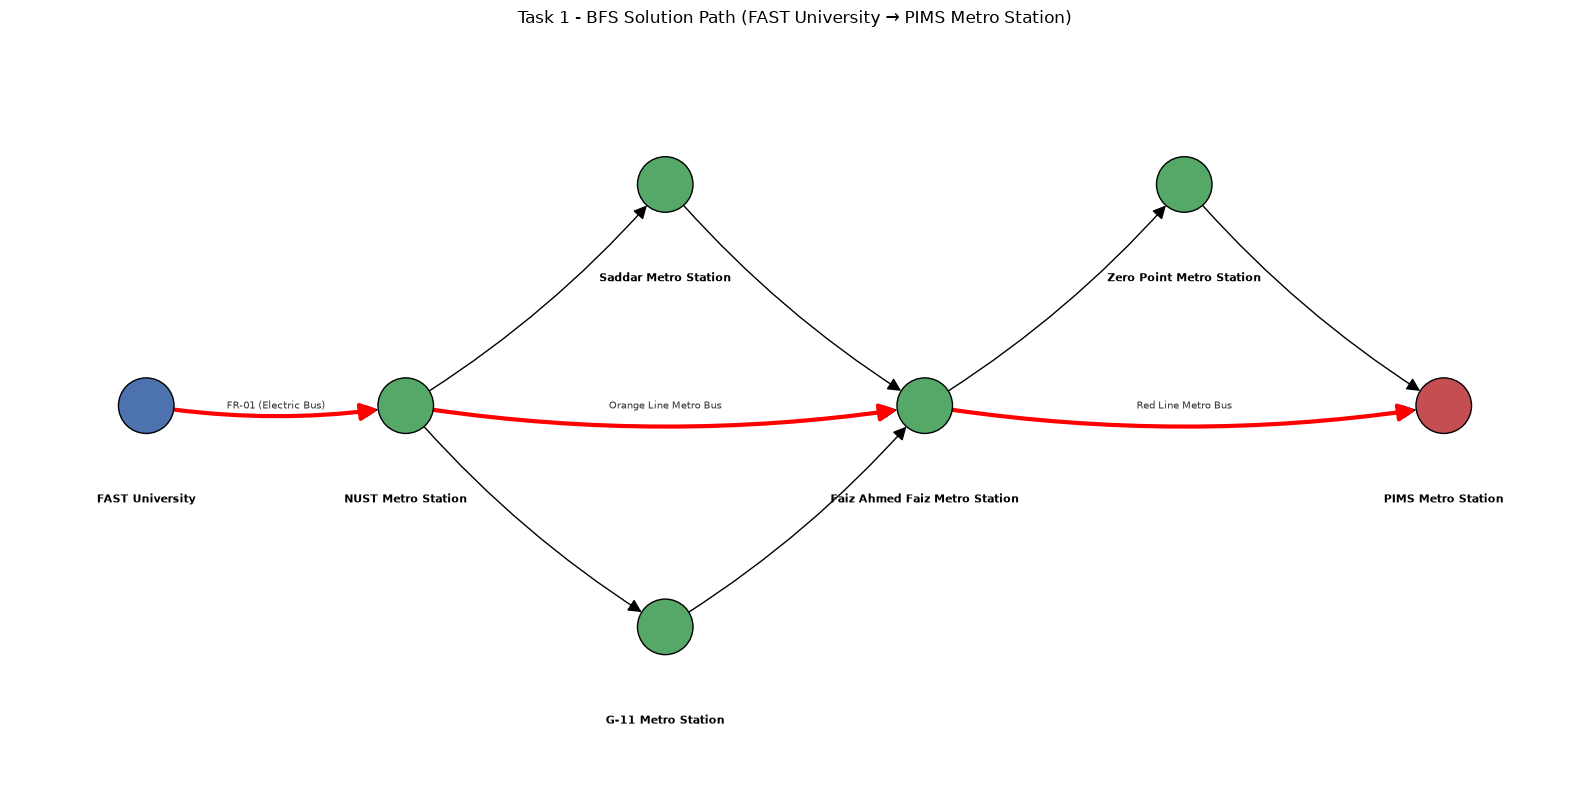

In [1]:
from collections import deque
import networkx as nx
import matplotlib.pyplot as plt

graph = {
    "FAST University": [
        "NUST Metro Station"
    ],

    "NUST Metro Station": [
        "Saddar Metro Station",
        "Faiz Ahmed Faiz Metro Station",
        "G-11 Metro Station"
    ],

    "Saddar Metro Station": [
        "Faiz Ahmed Faiz Metro Station"
    ],

    "G-11 Metro Station": [
        "Faiz Ahmed Faiz Metro Station"
    ],

    "Faiz Ahmed Faiz Metro Station": [
        "Zero Point Metro Station",
        "PIMS Metro Station"
    ],

    "Zero Point Metro Station": [
        "PIMS Metro Station"
    ],

    "PIMS Metro Station": []
}

edge_labels = {
    ("FAST University", "NUST Metro Station"): "FR-01 (Electric Bus)",
    ("NUST Metro Station", "Faiz Ahmed Faiz Metro Station"): "Orange Line Metro Bus",
    ("Faiz Ahmed Faiz Metro Station", "PIMS Metro Station"): "Red Line Metro Bus",
}


def bfs(graph, start, goal):

    queue = deque([start])
    visited = {start}
    parent = {start: None}
    level = {start: 0}
    expansion_order = []

    print("Initial Queue:", list(queue))

    while queue:
        current = queue.popleft()
        expansion_order.append(current)

        if current == goal:
            print(f"\nGoal '{goal}' found! Terminating search immediately.")
            break

        for neighbor in graph[current]:
            if neighbor not in visited:
                visited.add(neighbor)
                parent[neighbor] = current
                level[neighbor] = level[current] + 1
                queue.append(neighbor)

        print(f"Expanded: {current:35s} -> Frontier/Queue: {list(queue)}")

    path = []
    node = goal
    while node is not None:
        path.append(node)
        node = parent[node]
    path.reverse()

    return expansion_order, level, path


start = "FAST University"
goal = "PIMS Metro Station"

order, levels, path = bfs(
    graph,
    start,
    goal
)

print("\n RESULTS OF BFS SEARCH ")

print("Initial State:", start)
print("Goal State:", goal)

print("\nLevels:")
for node in path:
    print(f"Level {levels[node]}: {node}")

print("\nTraversal / Expansion Order:")
for node in order:
    print(node)

print("\nSolution Path:")
print(" \u2192 ".join(path))

print("\nNumber of Transitions:", len(path) - 1)


# NetworkX Visualization

G = nx.DiGraph()
for node, neighbors in graph.items():
    G.add_node(node)
    for neighbor in neighbors:
        G.add_edge(node, neighbor)

pos = {
    "FAST University": (0, 0),
    "NUST Metro Station": (2.5, 0),
    "Saddar Metro Station": (5, 1.3),
    "G-11 Metro Station": (5, -1.3),
    "Faiz Ahmed Faiz Metro Station": (7.5, 0),
    "Zero Point Metro Station": (10, 1.3),
    "PIMS Metro Station": (12.5, 0),
}

node_colors = []
for node in G.nodes():
    if node == start:
        node_colors.append("#4C72B0")
    elif node == goal:
        node_colors.append("#C44E52")
    else:
        node_colors.append("#55A868")

plt.figure(figsize=(16, 8))

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=1600, edgecolors="black")
nx.draw_networkx_edges(G, pos, node_size=1600, arrows=True, arrowsize=20, connectionstyle="arc3,rad=0.08")

label_pos = {node: (x, y - 0.55) for node, (x, y) in pos.items()}
nx.draw_networkx_labels(G, label_pos, font_size=8, font_color="black", font_weight="bold")
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7, font_color="#333333", label_pos=0.5)

path_edges = list(zip(path, path[1:]))
nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color="red", width=3, node_size=1600, arrows=True, arrowsize=25, connectionstyle="arc3,rad=0.08")

plt.title("Task 1 - BFS Solution Path (FAST University \u2192 PIMS Metro Station)")
plt.axis("off")
plt.ylim(-2.2, 2.2)
plt.tight_layout()
plt.show()


## Task 2: Tree Search vs Graph Search

In [2]:
from collections import deque
import networkx as nx
import matplotlib.pyplot as plt

# TASK 2 - PART 1: BFS on tree, no visited set

tree = {

    "Main Entrance": [
        "Reception",
        "Emergency Lobby"
    ],

    "Reception": [
        "Registration"
    ],

    "Registration": [
        "Main Corridor"
    ],

    "Main Corridor": [],

    "Emergency Lobby": [
        "Waiting Area"
    ],

    "Waiting Area": [
        "Radiology Department"
    ],

    "Radiology Department": []
}


def bfs_tree(graph, start, goal):

    queue = deque([start])
    parent = {start: None}
    expansion_order = []

    step = 1
    while queue:
        current = queue.popleft()
        expansion_order.append(current)

        if current == goal:
            print(f"Step {step}: Take -> {current}  (Goal Found!)")
            break

        added = []
        for neighbor in graph[current]:
            parent[neighbor] = current
            queue.append(neighbor)
            added.append(neighbor)

        print(f"Step {step}: Take -> {current}")
        print(f"Add: {', '.join(added) if added else '-'}")
        print(f"Queue: {list(queue)}\n")

        step += 1

    path = []
    node = goal
    while node is not None:
        path.append(node)
        node = parent[node]
    path.reverse()

    return expansion_order, path


start = "Main Entrance"
goal = "Radiology Department"

order, path = bfs_tree(tree,start,goal)

print("\nTraversal Order:")
print(" \u2192 ".join(order))

print("\nSolution Path:")
print(" \u2192 ".join(path))


Step 1: Take -> Main Entrance
Add: Reception, Emergency Lobby
Queue: ['Reception', 'Emergency Lobby']

Step 2: Take -> Reception
Add: Registration
Queue: ['Emergency Lobby', 'Registration']

Step 3: Take -> Emergency Lobby
Add: Waiting Area
Queue: ['Registration', 'Waiting Area']

Step 4: Take -> Registration
Add: Main Corridor
Queue: ['Waiting Area', 'Main Corridor']

Step 5: Take -> Waiting Area
Add: Radiology Department
Queue: ['Main Corridor', 'Radiology Department']

Step 6: Take -> Main Corridor
Add: -
Queue: ['Radiology Department']

Step 7: Take -> Radiology Department  (Goal Found!)

Traversal Order:
Main Entrance → Reception → Emergency Lobby → Registration → Waiting Area → Main Corridor → Radiology Department

Solution Path:
Main Entrance → Emergency Lobby → Waiting Area → Radiology Department


## Part 2A: BFS on Graph WITHOUT Visited Set

In [3]:
from collections import deque

# TASK 2 - PART 2A: BFS on graph, no visited set

hospital_graph = {

    "Main Entrance": [
        "Reception",
        "Emergency Lobby"
    ],

    "Reception": [
        "Registration"
    ],

    "Registration": [
        "Main Corridor"
    ],

    "Main Corridor": [
        "Waiting Area"
    ],

    "Emergency Lobby": [
        "Waiting Area"
    ],

    "Waiting Area": [
        "Radiology Department",
        "Main Corridor"
    ],

    "Radiology Department": []
}


def bfs_without_visited(graph, start, goal, max_steps=10):

    queue = deque([start])
    step = 1
    order = []

    print(f"{'Step':<6}{'Current Node':<25}{'Nodes Added':<35}{'Queue'}")

    while queue and step <= max_steps:
        current = queue.popleft()
        order.append(current)

        if current == goal:
            print(f"{step:<6}{current:<25}{'-':<35}{list(queue)}")
            print(f"\nGoal '{goal}' found at step {step}.")
            return order

        added = list(graph[current])
        for neighbor in added:
            queue.append(neighbor)

        print(f"{step:<6}{current:<25}{', '.join(added) if added else '-':<35}{list(queue)}")

        step += 1

    print("\nStopped after reaching the max_steps safety limit", max_steps)
    print("Without a visited set, 'Main Corridor' and 'Waiting Area' keep re-generating")
    print("each other through the cycle, so the queue keeps growing and the search")
    print("may never terminate on its own.")
    return order


order = bfs_without_visited(
    hospital_graph,
    "Main Entrance",
    "Radiology Department"
)


Step  Current Node             Nodes Added                        Queue
1     Main Entrance            Reception, Emergency Lobby         ['Reception', 'Emergency Lobby']
2     Reception                Registration                       ['Emergency Lobby', 'Registration']
3     Emergency Lobby          Waiting Area                       ['Registration', 'Waiting Area']
4     Registration             Main Corridor                      ['Waiting Area', 'Main Corridor']
5     Waiting Area             Radiology Department, Main Corridor['Main Corridor', 'Radiology Department', 'Main Corridor']
6     Main Corridor            Waiting Area                       ['Radiology Department', 'Main Corridor', 'Waiting Area']
7     Radiology Department     -                                  ['Main Corridor', 'Waiting Area']

Goal 'Radiology Department' found at step 7.


the real problem demonstrated by this implementation is that repeated states continue to be generated, and if the goal were unreachable, the search could continue indefinitely.

The max_steps parameter is therefore only a safety limit for the demonstration, it is not part of the BFS concept.

## Part 2B: BFS on Graph WITH Visited Set

In [4]:
from collections import deque

# TASK 2 - PART 2B: BFS on graph, with visited set

def bfs_graph(graph, start, goal):

    queue = deque([start])
    visited = {start}
    parent = {start: None}
    order = []

    step = 1
    while queue:
        current = queue.popleft()
        order.append(current)

        if current == goal:
            print(f"Step {step}: Take -> {current}  (Goal Found!)")
            print(f"Visited: {visited}")
            break

        added = []
        for neighbor in graph[current]:
            if neighbor not in visited:
                visited.add(neighbor)
                parent[neighbor] = current
                queue.append(neighbor)
                added.append(neighbor)

        print(f"Step {step}: Take -> {current}")
        print(f"Add: {', '.join(added) if added else '-'}")
        print(f"Queue: {list(queue)}")
        print(f"Visited: {visited}\n")

        step += 1

    path = []
    node = goal
    while node is not None:
        path.append(node)
        node = parent[node]
    path.reverse()

    return order, visited, path


order, visited, path = bfs_graph(
    hospital_graph,
    "Main Entrance",
    "Radiology Department"
)


print("\nTraversal Order:")
print(" \u2192 ".join(order))

print("\nVisited Set:")
print(visited)

print("\nSolution Path:")
print(" \u2192 ".join(path))


Step 1: Take -> Main Entrance
Add: Reception, Emergency Lobby
Queue: ['Reception', 'Emergency Lobby']
Visited: {'Reception', 'Emergency Lobby', 'Main Entrance'}

Step 2: Take -> Reception
Add: Registration
Queue: ['Emergency Lobby', 'Registration']
Visited: {'Reception', 'Emergency Lobby', 'Main Entrance', 'Registration'}

Step 3: Take -> Emergency Lobby
Add: Waiting Area
Queue: ['Registration', 'Waiting Area']
Visited: {'Emergency Lobby', 'Main Entrance', 'Reception', 'Waiting Area', 'Registration'}

Step 4: Take -> Registration
Add: Main Corridor
Queue: ['Waiting Area', 'Main Corridor']
Visited: {'Emergency Lobby', 'Main Entrance', 'Main Corridor', 'Reception', 'Waiting Area', 'Registration'}

Step 5: Take -> Waiting Area
Add: Radiology Department
Queue: ['Main Corridor', 'Radiology Department']
Visited: {'Emergency Lobby', 'Main Entrance', 'Main Corridor', 'Radiology Department', 'Reception', 'Waiting Area', 'Registration'}

Step 6: Take -> Main Corridor
Add: -
Queue: ['Radiology De

## NetworkX Visualization

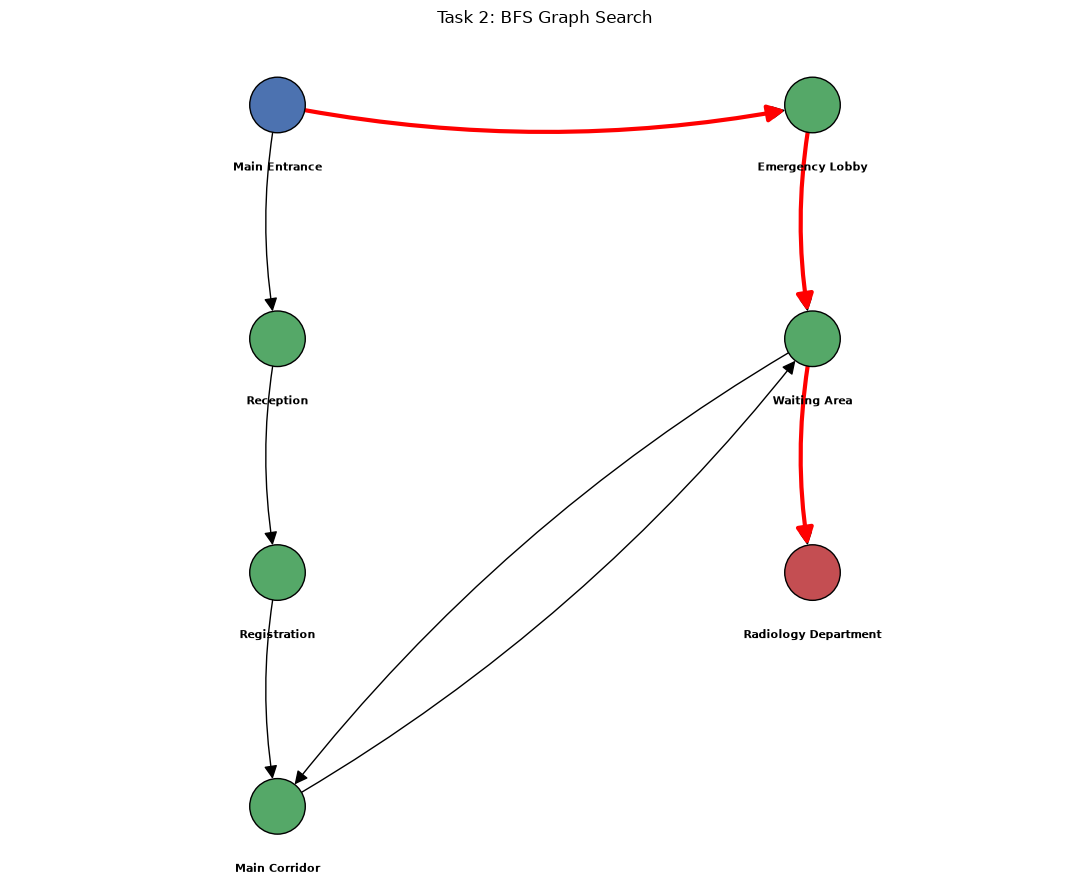

In [5]:
# TASK 2 VISUALIZATION

G = nx.DiGraph()
for node, neighbors in hospital_graph.items():
    G.add_node(node)
    for neighbor in neighbors:
        G.add_edge(node, neighbor)

pos = {
    "Main Entrance": (0, 0),
    "Reception": (0, -1.5),
    "Emergency Lobby": (2, 0),
    "Registration": (0, -3),
    "Waiting Area": (2, -1.5),
    "Main Corridor": (0, -4.5),
    "Radiology Department": (2, -3),
}

node_colors = []
for node in G.nodes():
    if node == "Main Entrance":
        node_colors.append("#4C72B0")
    elif node == "Radiology Department":
        node_colors.append("#C44E52")
    else:
        node_colors.append("#55A868")

plt.figure(figsize=(11, 9))

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=1600, edgecolors="black")
nx.draw_networkx_edges(G, pos, node_size=1600, arrows=True, arrowsize=20, connectionstyle="arc3,rad=0.1")

label_pos = {node: (x, y - 0.4) for node, (x, y) in pos.items()}
nx.draw_networkx_labels(G, label_pos, font_size=8, font_color="black", font_weight="bold")

path_edges = list(zip(path, path[1:]))
nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color="red", width=3, node_size=1600, arrows=True, arrowsize=25, connectionstyle="arc3,rad=0.1")

plt.title("Task 2: BFS Graph Search")
plt.axis("off")
plt.xlim(-1, 3)
plt.tight_layout()
plt.show()


## Task 3: DFS for Warehouse Robot Exploration

In [6]:
import networkx as nx
import matplotlib.pyplot as plt

# TASK 3: DFS - WAREHOUSE ROBOT

warehouse = {

    "Receiving Area": [
        "Main Aisle"
    ],

    "Main Aisle": [
        "Electronics",
        "Grocery",
        "Packaging"
    ],

    "Electronics": [
        "Phones",
        "Laptops"
    ],

    "Phones": [
        "Inspection Area"
    ],

    "Laptops": [],

    "Grocery": [
        "Food",
        "Drinks"
    ],

    "Food": [],

    "Drinks": [],

    "Packaging": [
        "Dispatch"
    ],

    "Dispatch": [],

    "Inspection Area": []
}


def dfs(graph, start, goal):

    stack = [start]
    visited = set()
    parent = {start: None}
    traversal_order = []

    step = 1
    while stack:
        current = stack.pop()
        if current in visited:
            continue

        visited.add(current)
        traversal_order.append(current)

        print(f"Step {step}: Pop -> {current:20s} Stack: {stack}")
        step += 1

        if current == goal:
            print(f"\nGoal '{goal}' found! Terminating search immediately.")
            break

        # reversed so the first-listed neighbor ends up on top of the stack
        for neighbor in reversed(graph[current]):
            if neighbor not in visited:
                if neighbor not in parent:
                    parent[neighbor] = current
                stack.append(neighbor)

    path = []
    node = goal
    while node is not None:
        path.append(node)
        node = parent.get(node)
    path.reverse()

    return traversal_order, path, visited


start = "Receiving Area"
goal = "Inspection Area"

order, path, visited = dfs(
    warehouse,
    start,
    goal
)

print("\n RESULTS")

print("Traversal Order:")
print(" \u2192 ".join(order))

print("\nSolution Path:")
print(" \u2192 ".join(path))

print("\nNumber of States Explored:")
print(len(visited))


Step 1: Pop -> Receiving Area       Stack: []
Step 2: Pop -> Main Aisle           Stack: []
Step 3: Pop -> Electronics          Stack: ['Packaging', 'Grocery']
Step 4: Pop -> Phones               Stack: ['Packaging', 'Grocery', 'Laptops']
Step 5: Pop -> Inspection Area      Stack: ['Packaging', 'Grocery', 'Laptops']

Goal 'Inspection Area' found! Terminating search immediately.

 RESULTS
Traversal Order:
Receiving Area → Main Aisle → Electronics → Phones → Inspection Area

Solution Path:
Receiving Area → Main Aisle → Electronics → Phones → Inspection Area

Number of States Explored:
5


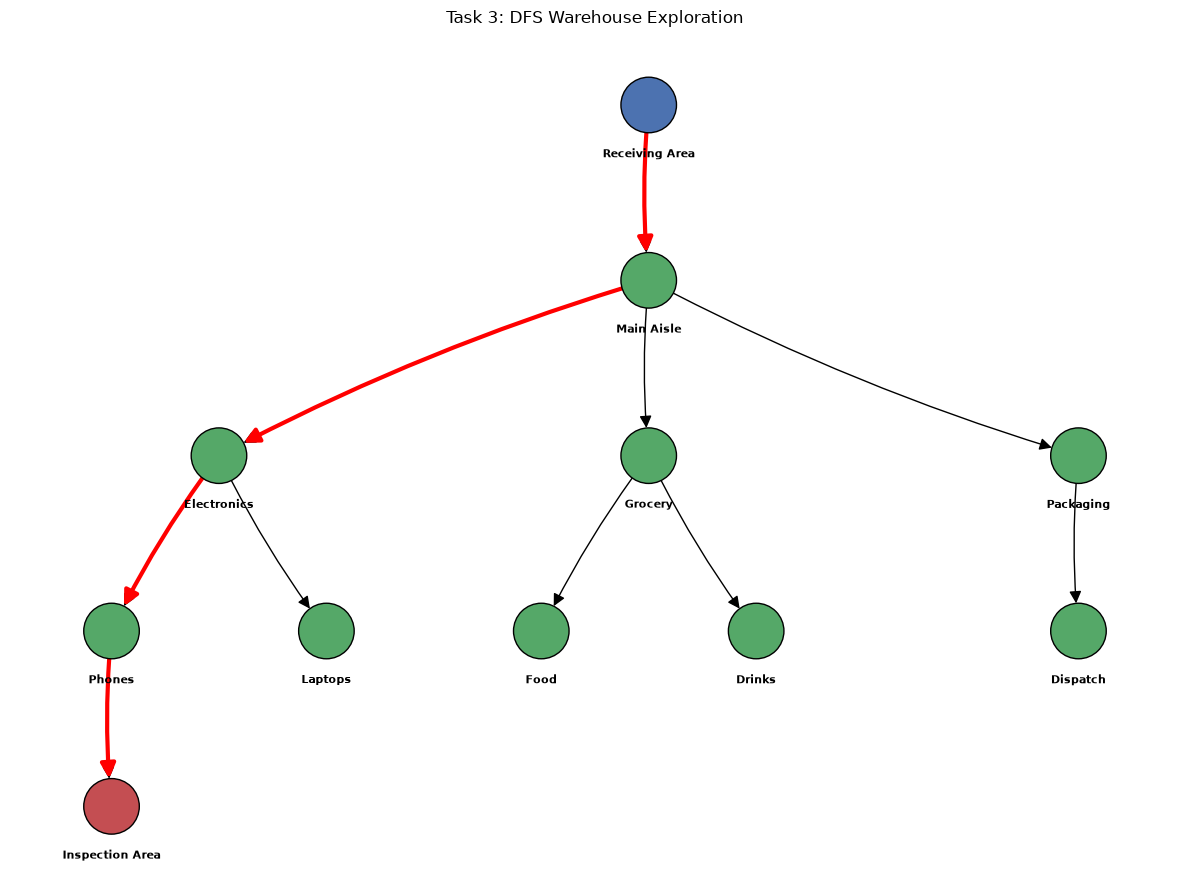

In [7]:
# TASK 3 NetworkX VISUALIZATION

G = nx.DiGraph()
for node, neighbors in warehouse.items():
    G.add_node(node)
    for neighbor in neighbors:
        G.add_edge(node, neighbor)

pos = {
    "Receiving Area": (2, 4),
    "Main Aisle": (2, 3),
    "Electronics": (0, 2),
    "Grocery": (2, 2),
    "Packaging": (4, 2),
    "Phones": (-0.5, 1),
    "Laptops": (0.5, 1),
    "Food": (1.5, 1),
    "Drinks": (2.5, 1),
    "Dispatch": (4, 1),
    "Inspection Area": (-0.5, 0),
}

node_colors = []
for node in G.nodes():
    if node == start:
        node_colors.append("#4C72B0")
    elif node == goal:
        node_colors.append("#C44E52")
    else:
        node_colors.append("#55A868")

plt.figure(figsize=(12, 9))

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=1600, edgecolors="black")
nx.draw_networkx_edges(G, pos, node_size=1600, arrows=True, arrowsize=18, connectionstyle="arc3,rad=0.05")

label_pos = {node: (x, y - 0.28) for node, (x, y) in pos.items()}
nx.draw_networkx_labels(G, label_pos, font_size=8, font_color="black", font_weight="bold")

path_edges = list(zip(path, path[1:]))
nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color="red", width=3, node_size=1600, arrows=True, arrowsize=22, connectionstyle="arc3,rad=0.05")

plt.title("Task 3: DFS Warehouse Exploration")
plt.axis("off")
plt.tight_layout()
plt.show()


## Task 4: UCS for Delivery Route Optimization

In [8]:
import heapq
import networkx as nx
import matplotlib.pyplot as plt

# TASK 4: UCS - DELIVERY ROUTE

graph = {
    "Islamabad Delivery Hub": [
        ("I-8 Markaz", 4),
        ("H-8 Markaz", 2)
    ],

    "I-8 Markaz": [
        ("F-8 Markaz", 5)
    ],

    "H-8 Markaz": [
        ("Blue Area Delivery Point", 6)
    ],

    "F-8 Markaz": [
        ("Blue Area Delivery Point", 3)
    ],

    "Blue Area Delivery Point": []
}


def ucs(graph, start, goal):

    priority_queue = [(0, start)]
    best_cost = {start: 0}
    parent = {start: None}
    traversal_order = []

    step = 1
    while priority_queue:
        total_cost, current = heapq.heappop(priority_queue)

        # skip stale entries already beaten by a cheaper path
        if total_cost > best_cost.get(current, float("inf")):
            continue

        traversal_order.append(current)

        print(f"Step {step}: Expand -> {current:25s} Cumulative Cost: {total_cost:<5} "
              f"Priority Queue: {sorted(priority_queue)}")
        step += 1

        if current == goal:
            print(f"\nGoal '{goal}' found with total cost {total_cost}.")
            break

        for neighbor, edge_cost in graph[current]:
            new_cost = total_cost + edge_cost
            if new_cost < best_cost.get(neighbor, float("inf")):
                best_cost[neighbor] = new_cost
                parent[neighbor] = current
                heapq.heappush(priority_queue, (new_cost, neighbor))

    path = []
    node = goal
    while node is not None:
        path.append(node)
        node = parent.get(node)
    path.reverse()

    return traversal_order, path, best_cost


start = "Islamabad Delivery Hub"
goal = "Blue Area Delivery Point"

traversal_order, path, best_cost = ucs(
    graph,
    start,
    goal
)

print("\nTraversal Order:")
print(traversal_order)

print("\nSolution Path:")
print(" \u2192 ".join(path))

print("\nTotal Path Cost:")
print(best_cost[goal])


Step 1: Expand -> Islamabad Delivery Hub    Cumulative Cost: 0     Priority Queue: []
Step 2: Expand -> H-8 Markaz                Cumulative Cost: 2     Priority Queue: [(4, 'I-8 Markaz')]
Step 3: Expand -> I-8 Markaz                Cumulative Cost: 4     Priority Queue: [(8, 'Blue Area Delivery Point')]
Step 4: Expand -> Blue Area Delivery Point  Cumulative Cost: 8     Priority Queue: [(9, 'F-8 Markaz')]

Goal 'Blue Area Delivery Point' found with total cost 8.

Traversal Order:
['Islamabad Delivery Hub', 'H-8 Markaz', 'I-8 Markaz', 'Blue Area Delivery Point']

Solution Path:
Islamabad Delivery Hub → H-8 Markaz → Blue Area Delivery Point

Total Path Cost:
8


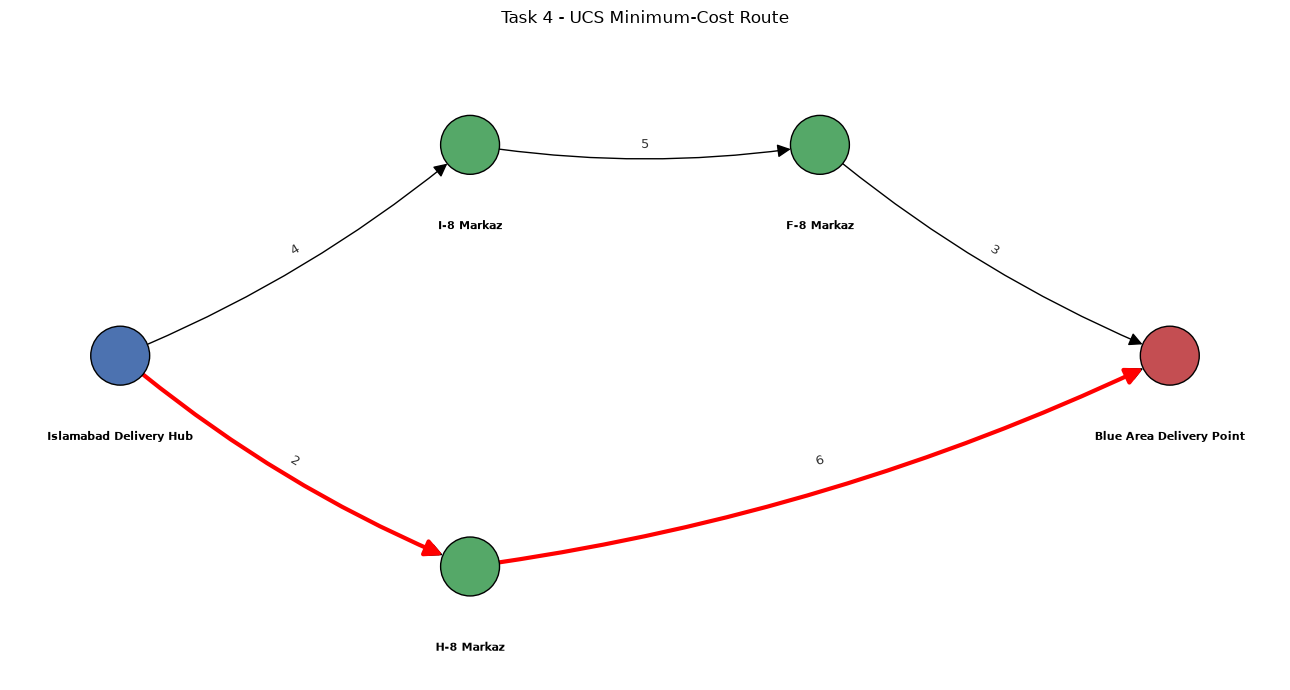

In [9]:
# TASK 4 NETWORKX VISUALIZATION

G = nx.DiGraph()
for node, neighbors in graph.items():
    G.add_node(node)
    for neighbor, weight in neighbors:
        G.add_edge(node, neighbor, weight=weight)

pos = {
    "Islamabad Delivery Hub": (0, 0),
    "I-8 Markaz": (2, 1.3),
    "H-8 Markaz": (2, -1.3),
    "F-8 Markaz": (4, 1.3),
    "Blue Area Delivery Point": (6, 0),
}

node_colors = []
for node in G.nodes():
    if node == start:
        node_colors.append("#4C72B0")
    elif node == goal:
        node_colors.append("#C44E52")
    else:
        node_colors.append("#55A868")

plt.figure(figsize=(13, 7))

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=1800, edgecolors="black")
nx.draw_networkx_edges(G, pos, node_size=1800, arrows=True, arrowsize=20, connectionstyle="arc3,rad=0.08")

label_pos = {node: (x, y - 0.5) for node, (x, y) in pos.items()}
nx.draw_networkx_labels(G, label_pos, font_size=8, font_color="black", font_weight="bold")

edge_weights = nx.get_edge_attributes(G, "weight")
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_weights, font_size=9, font_color="#333333")

path_edges = list(zip(path, path[1:]))
nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color="red", width=3, node_size=1800, arrows=True, arrowsize=25, connectionstyle="arc3,rad=0.08")

plt.title("Task 4 - UCS Minimum-Cost Route")
plt.axis("off")
plt.ylim(-2, 2)
plt.tight_layout()
plt.show()
